In [155]:
import torch

print(torch.__version__)          # 설치된 버전 확인
print(torch.cuda.is_available())  # GPU 사용 가능 여부

2.5.1+cu121
True


In [156]:
scalar = torch.tensor(36.5)
vector = torch.tensor([85, 90, 78])
matrix = torch.tensor([[85, 90, 78],
                       [70, 88, 95]])

print(scalar.ndim, vector.ndim, matrix.ndim)   # 0 1 2
print(scalar.shape, vector.shape, matrix.shape)

0 1 2
torch.Size([]) torch.Size([3]) torch.Size([2, 3])


In [157]:
# 직접 값을 넣어 생성
a = torch.tensor([1.0, 2.0, 3.0])

# 특정 값으로 채워 생성
zeros = torch.zeros(2, 3)      # 0으로 채운 2x3
ones  = torch.ones(2, 3)       # 1로 채운 2x3
rand  = torch.rand(2, 3)       # 0~1 균등분포 난수
randn = torch.randn(2, 3)      # 표준정규분포 난수

# 범위로 생성
seq = torch.arange(0, 10, 2)   # 0, 2, 4, 6, 8

# 기존 텐서와 같은 shape로 생성
like = torch.zeros_like(rand)

torch.manual_seed(42)
print(torch.rand(2))  # 실행할 때마다 같은 값
print(a)  # 실행할 때마다 같은 값
print(zeros)  # 실행할 때마다 같은 값
print(ones)  # 실행할 때마다 같은 값
print(rand)  # 실행할 때마다 같은 값
print(randn)  # 실행할 때마다 같은 값
print(seq)  # 실행할 때마다 같은 값

tensor([0.8823, 0.9150])
tensor([1., 2., 3.])
tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.1644, 0.6161, 0.0954],
        [0.4779, 0.0616, 0.3842]])
tensor([[-0.4640,  0.6014,  0.9867],
        [ 0.0784,  0.5192,  0.4462]])
tensor([0, 2, 4, 6, 8])


In [158]:
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([10.0, 20.0, 30.0])

print(x + y)   # tensor([11., 22., 33.])
print(x * y)   # tensor([10., 40., 90.])  곱셈도 원소끼리
print(x ** 2)  # tensor([1., 4., 9.])

tensor([11., 22., 33.])
tensor([10., 40., 90.])
tensor([1., 4., 9.])


In [159]:
A = torch.tensor([[1., 2.],
                  [3., 4.]])
B = torch.tensor([[5., 6.],
                  [7., 8.]])

print(A * B)   # 원소별 곱
print(A @ B)   # 행렬 곱

tensor([[ 5., 12.],
        [21., 32.]])
tensor([[19., 22.],
        [43., 50.]])


In [160]:
# 1. 학생 3명의 [중간, 기말] 점수 (3행 2열 행렬)
student_scores = torch.tensor([
    [80.0, 100.0],  # 학생 A
    [90.0,  70.0],  # 학생 B
    [60.0,  80.0]   # 학생 C
])

# 2. 중간/기말 반영 비율 (2행 1열 벡터)
weights = torch.tensor([0.4, 0.6])

# 3. 행렬곱(@)으로 전교생 내신 점수 한 번에 계산!
final_scores = student_scores @ weights

print(final_scores)

tensor([92., 78., 72.])


In [161]:
t = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])

print(t.sum())          # 전체 합: 21
print(t.mean())         # 전체 평균: 3.5
print(t.sum(dim=0))     # 열 방향 합: [5., 7., 9.]
print(t.sum(dim=1))     # 행 방향 합: [6., 15.]
print(t.max(), t.argmax())  # 최댓값과 그 위치

tensor(21.)
tensor(3.5000)
tensor([5., 7., 9.])
tensor([ 6., 15.])
tensor(6.) tensor(5)


In [162]:
import numpy as np

np_arr = np.array([1, 2, 3])
t = torch.from_numpy(np_arr)   # NumPy -> Tensor
back = t.numpy()               # Tensor -> NumPy

np_arr[0] = 100
print(t)   # tensor([100, 2, 3])  같이 바뀜

tensor([100,   2,   3])


In [163]:
s1 = torch.zeros(3, 4)

print(s1)
print(s1.shape)

s2 = torch.arange(0, 21, 4)

print(s2)

torch.manual_seed(0)
s3 = torch.rand(2, 2)
print(s3)

s4 = s3*10
print(s4)

s5A = torch.tensor([[1, 2], [3, 4]])
s5B = torch.tensor([[5, 6], [7, 8]])

print(s5A*s5B)
print(s5A@s5B)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
torch.Size([3, 4])
tensor([ 0,  4,  8, 12, 16, 20])
tensor([[0.4963, 0.7682],
        [0.0885, 0.1320]])
tensor([[4.9626, 7.6822],
        [0.8848, 1.3203]])
tensor([[ 5, 12],
        [21, 32]])
tensor([[19, 22],
        [43, 50]])


In [164]:
t = torch.arange(12).reshape(3, 4)
# tensor([[ 0,  1,  2,  3],
#         [ 4,  5,  6,  7],
#         [ 8,  9, 10, 11]])

print(t[0])        # 첫 번째 행
print(t[0, 2])     # 0행 2열의 원소: 2
print(t[:, 1])     # 모든 행의 1열: [1, 5, 9]
print(t[1:, 2:])   # 1행 이후, 2열 이후
print(t[-1])       # 마지막 행
print(t[t > 5])    # 5보다 큰 원소만: [ 6,  7,  8,  9, 10, 11]

tensor([0, 1, 2, 3])
tensor(2)
tensor([1, 5, 9])
tensor([[ 6,  7],
        [10, 11]])
tensor([ 8,  9, 10, 11])
tensor([ 6,  7,  8,  9, 10, 11])


In [165]:
t = torch.arange(12)
a = t.reshape(3, 4)
b = t.reshape(2, 6)
c = t.reshape(4, -1)   # -1은 "알아서 계산해줘": (4, 3)이 됨

print(a)
print(b)
print(c)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


In [166]:
img = torch.rand(3, 224, 224)       # (채널, 높이, 너비)
hwc = img.permute(1, 2, 0)          # (높이, 너비, 채널)로 순서 변경
print(hwc.shape)                    # torch.Size([224, 224, 3])

torch.Size([224, 224, 3])


In [167]:
t = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])
print(t.reshape(3, 2))   # [[1,2],[3,4],[5,6]]  읽는 순서 유지
print(t.permute(1, 0))   # [[1,4],[2,5],[3,6]]  행과 열이 뒤집힘

tensor([[1, 2],
        [3, 4],
        [5, 6]])
tensor([[1, 4],
        [2, 5],
        [3, 6]])


In [168]:
t = torch.rand(3, 4)
t2 = t.unsqueeze(0)    # (1, 3, 4)  배치 차원 추가에 자주 사용
t3 = t2.squeeze(0)     # 다시 (3, 4)

print(t)
print(t2)
print(t3)

tensor([[0.0793, 0.2385, 0.0012, 0.5246],
        [0.1162, 0.4818, 0.3839, 0.8934],
        [0.4135, 0.6571, 0.5522, 0.4148]])
tensor([[[0.0793, 0.2385, 0.0012, 0.5246],
         [0.1162, 0.4818, 0.3839, 0.8934],
         [0.4135, 0.6571, 0.5522, 0.4148]]])
tensor([[0.0793, 0.2385, 0.0012, 0.5246],
        [0.1162, 0.4818, 0.3839, 0.8934],
        [0.4135, 0.6571, 0.5522, 0.4148]])


In [169]:
a = torch.rand(2, 3)
b = torch.rand(2, 3)

cat0 = torch.cat([a, b], dim=0)     # (4, 3)  행 방향으로 이어붙임
cat1 = torch.cat([a, b], dim=1)     # (2, 6)  열 방향으로 이어붙임
stacked = torch.stack([a, b])       # (2, 2, 3)  새 차원이 생김

print(a)
print(b)
print(cat0)
print(cat1)
print(stacked)

tensor([[0.7771, 0.6295, 0.1894],
        [0.7843, 0.6775, 0.7653]])
tensor([[0.8990, 0.5795, 0.3956],
        [0.7390, 0.3317, 0.5313]])
tensor([[0.7771, 0.6295, 0.1894],
        [0.7843, 0.6775, 0.7653],
        [0.8990, 0.5795, 0.3956],
        [0.7390, 0.3317, 0.5313]])
tensor([[0.7771, 0.6295, 0.1894, 0.8990, 0.5795, 0.3956],
        [0.7843, 0.6775, 0.7653, 0.7390, 0.3317, 0.5313]])
tensor([[[0.7771, 0.6295, 0.1894],
         [0.7843, 0.6775, 0.7653]],

        [[0.8990, 0.5795, 0.3956],
         [0.7390, 0.3317, 0.5313]]])


In [170]:
t = torch.arange(10)
print(torch.chunk(t, 2))       # 5개씩 2덩어리
print(torch.split(t, [3, 7]))  # 3개, 7개로 분할

(tensor([0, 1, 2, 3, 4]), tensor([5, 6, 7, 8, 9]))
(tensor([0, 1, 2]), tensor([3, 4, 5, 6, 7, 8, 9]))


In [171]:
t = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])   # (2, 3)

print(t + 10)                       # 스칼라가 (2, 3)으로 확장
print(t + torch.tensor([10., 20., 30.]))   # (3,)이 (2, 3)으로 확장

tensor([[11., 12., 13.],
        [14., 15., 16.]])
tensor([[11., 22., 33.],
        [14., 25., 36.]])


In [172]:
a = torch.tensor([1, 2, 3])        # int64
b = torch.tensor([1., 2., 3.])     # float32
print(a.dtype, b.dtype)

c = a.float()            # int64 -> float32
d = b.to(torch.int64)    # float32 -> int64

print(c.dtype, d.dtype)

torch.int64 torch.float32
torch.float32 torch.int64


In [173]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

t = torch.rand(3, 3)
t_gpu = t.to(device)      # GPU로 이동
print(t_gpu.device)

cuda
cuda:0


In [174]:
a = torch.rand(2, 2)               # CPU
b = torch.rand(2, 2).to(device)    # GPU
# a + b   # RuntimeError: Expected all tensors to be on the same device

In [175]:
arr = t_gpu.cpu().numpy()

In [176]:
import time

size = 4096
a_cpu = torch.rand(size, size)
b_cpu = torch.rand(size, size)

start = time.time()
_ = a_cpu @ b_cpu
print(f"CPU: {time.time() - start:.3f}초")

if torch.cuda.is_available():
    a_gpu, b_gpu = a_cpu.to("cuda"), b_cpu.to("cuda")
    _ = a_gpu @ b_gpu            # 워밍업
    torch.cuda.synchronize()
    start = time.time()
    _ = a_gpu @ b_gpu
    torch.cuda.synchronize()
    print(f"GPU: {time.time() - start:.3f}초")

CPU: 0.817초
GPU: 0.018초


In [177]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2          # y = x^2

y.backward()        # dy/dx 계산
print(x.grad)       # tensor(6.)  = 2x = 2*3

tensor(6.)


In [178]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(4.0)                 # 입력 데이터는 추적 불필요

y = w * x + b                         # y = 2*4 + 1 = 9
y.backward()

print(w.grad)   # tensor(4.)  dy/dw = x = 4
print(b.grad)   # tensor(1.)  dy/db = 1

tensor(4.)
tensor(1.)


In [179]:
x = torch.rand(3, requires_grad=True)
y = (x ** 2).sum()    # sum으로 스칼라를 만든 뒤
y.backward()          # backward 호출
print(x.grad)         # 2x와 일치

tensor([0.3538, 0.5859, 1.3977])


In [180]:
x = torch.tensor(3.0, requires_grad=True)

with torch.no_grad():
    y = x ** 2
print(y.requires_grad)   # False. 이 블록 안의 연산은 기록되지 않음

z = x ** 2
z_detached = z.detach()   # 값은 같지만 그래프와 연결이 끊긴 텐서

print(z_detached)

False
tensor(9.)


In [181]:
x = torch.tensor(3.0, requires_grad=True)

y1 = x ** 2
y1.backward()
print(x.grad)   # tensor(6.)

y2 = x ** 2
y2.backward()
print(x.grad)   # tensor(12.)  6이 아니라 6+6!

tensor(6.)
tensor(12.)


In [182]:
x.grad.zero_()   # grad를 0으로 초기화

tensor(0.)

In [183]:
import matplotlib.pyplot as plt

# 정답이 y = 3x + 2인 데이터 초기 설정
x_data = torch.tensor([1.0, 2.0, 3.0, 4.0])
y_data = torch.tensor([5.0, 8.0, 11.0, 14.0])

# 아무 값으로 시작
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.01   # 학습률: 한 걸음의 크기

# --- 시각화를 위해 값을 저장할 빈 리스트 생성 ---
loss_history = []
w_history = []
b_history = []

# 모델 학습
for step in range(1000):
    y_pred = w * x_data + b               # 1. 예측 (forward)
    loss = ((y_pred - y_data) ** 2).mean()  # 2. 손실 계산

    loss.backward()                       # 3. 미분 계산 (backward)

    with torch.no_grad():                 # 4. 파라미터 업데이트
        w -= lr * w.grad
        b -= lr * b.grad

# --- 현재 스텝의 값들을 리스트에 저장 (.item()을 써서 파이썬 숫자로 변환) ---
    loss_history.append(loss.item())
    w_history.append(w.item())
    b_history.append(b.item())

    w.grad.zero_()                        # 5. 그래디언트 초기화
    b.grad.zero_()

    if step % 50 == 0:
        print(f"step {step}: loss={loss.item():.4f}, w={w.item():.3f}, b={b.item():.3f}")

print(f"최종: w={w.item():.3f}, b={b.item():.3f}")   # w은3, b는2에 점차 가까워짐

step 0: loss=101.5000, w=0.550, b=0.190
step 50: loss=0.0954, w=3.256, b=1.246
step 100: loss=0.0707, w=3.221, b=1.351
step 150: loss=0.0524, w=3.190, b=1.442
step 200: loss=0.0388, w=3.163, b=1.519
step 250: loss=0.0288, w=3.141, b=1.586
step 300: loss=0.0213, w=3.121, b=1.644
step 350: loss=0.0158, w=3.104, b=1.693
step 400: loss=0.0117, w=3.090, b=1.736
step 450: loss=0.0087, w=3.077, b=1.773
step 500: loss=0.0064, w=3.066, b=1.805
step 550: loss=0.0048, w=3.057, b=1.832
step 600: loss=0.0035, w=3.049, b=1.855
step 650: loss=0.0026, w=3.042, b=1.875
step 700: loss=0.0019, w=3.037, b=1.893
step 750: loss=0.0014, w=3.031, b=1.908
step 800: loss=0.0011, w=3.027, b=1.920
step 850: loss=0.0008, w=3.023, b=1.932
step 900: loss=0.0006, w=3.020, b=1.941
step 950: loss=0.0004, w=3.017, b=1.949
최종: w=3.015, b=1.956


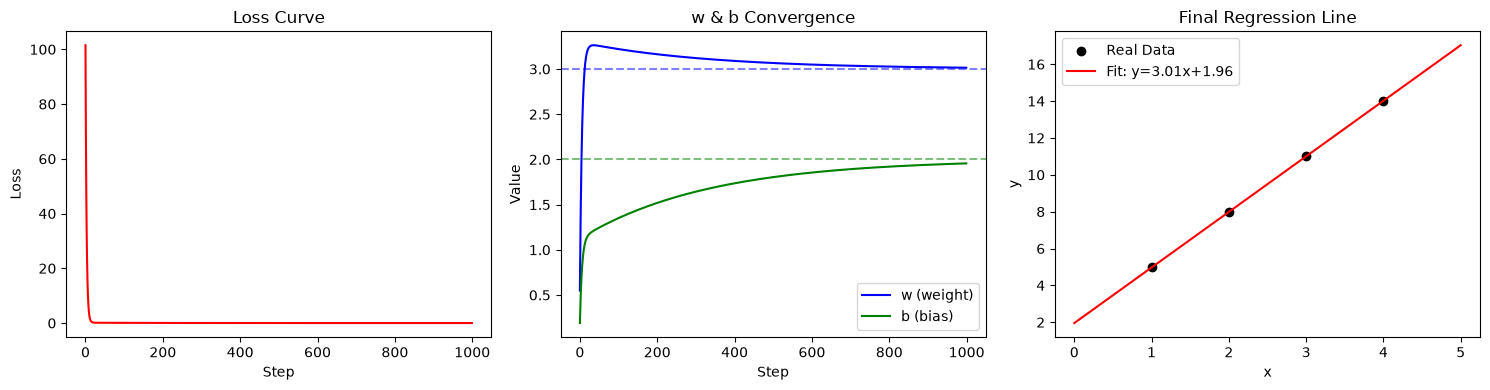

In [184]:
# 그래프 시각화
plt.figure(figsize=(15, 4)) # 전체 그래프 크기 설정

# 첫 번째 그래프: 손실(Loss) 변화
plt.subplot(1, 3, 1)
plt.plot(loss_history, color='red')
plt.title('Loss Curve')
plt.xlabel('Step')
plt.ylabel('Loss')

# 두 번째 그래프: 파라미터(w, b) 수렴 과정
plt.subplot(1, 3, 2)
plt.plot(w_history, label='w (weight)', color='blue')
plt.plot(b_history, label='b (bias)', color='green')
plt.axhline(y=3, color='blue', linestyle='--', alpha=0.5) # w 정답선(3)
plt.axhline(y=2, color='green', linestyle='--', alpha=0.5) # b 정답선(2)
plt.title('w & b Convergence')
plt.xlabel('Step')
plt.ylabel('Value')
plt.legend()

# 세 번째 그래프: 실제 데이터와 학습된 회귀선
plt.subplot(1, 3, 3)
plt.scatter(x_data.numpy(), y_data.numpy(), color='black', label='Real Data') # 원본 데이터 점
x_line = torch.linspace(0, 5, 100) # 직선을 그리기 위한 x값 생성
y_line = w.item() * x_line + b.item() # 최종 w, b를 이용한 예측 y값
plt.plot(x_line.numpy(), y_line.numpy(), color='red', label=f'Fit: y={w.item():.2f}x+{b.item():.2f}')
plt.title('Final Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

In [185]:
import torch.nn as nn

class MyFirstModel(nn.Module):
    def __init__(self):
        super().__init__()                 # 반드시 첫 줄에
        self.layer = nn.Linear(3, 1)       # 입력 3개 -> 출력 1개

    def forward(self, x):
        return self.layer(x)

model = MyFirstModel()
print(model)

MyFirstModel(
  (layer): Linear(in_features=3, out_features=1, bias=True)
)


In [186]:
x = torch.rand(5, 3)     # 샘플 5개, 특성 3개
out = model(x)           # model.forward(x)가 아니라 model(x)로 호출
print(out.shape)         # torch.Size([5, 1])

torch.Size([5, 1])


In [187]:
layer = nn.Linear(3, 2)
print(layer.weight.shape)   # torch.Size([2, 3])
print(layer.bias.shape)     # torch.Size([2])
print(layer.weight.requires_grad)   # True. 이미 추적이 켜져 있음

torch.Size([2, 3])
torch.Size([2])
True


In [188]:
for name, p in model.named_parameters():
    print(name, p.shape, p.numel())

total = sum(p.numel() for p in model.parameters())
print(f"총 파라미터: {total}개")

layer.weight torch.Size([1, 3]) 3
layer.bias torch.Size([1]) 1
총 파라미터: 4개


In [189]:
relu = nn.ReLU()        # max(0, x). 음수를 0으로. 현재 기본 선택지
sigmoid = nn.Sigmoid()  # 0~1 사이로 압축. 이진 분류의 출력에 사용
tanh = nn.Tanh()        # -1~1 사이로 압축

x = torch.linspace(-3, 3, 7)
print(relu(x))
print(sigmoid(x))

tensor([0., 0., 0., 0., 1., 2., 3.])
tensor([0.0474, 0.1192, 0.2689, 0.5000, 0.7311, 0.8808, 0.9526])


In [190]:
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=10, bias=True)
)


In [191]:
loss_fn = nn.MSELoss()
pred = torch.tensor([2.5, 0.0])
target = torch.tensor([3.0, -0.5])
print(loss_fn(pred, target))   # (0.5^2 + 0.5^2) / 2 = 0.25

tensor(0.2500)


In [192]:
loss_fn = nn.CrossEntropyLoss()
pred = torch.tensor([[2.0, 0.5, 0.1],     # 샘플 1의 클래스별 점수(로짓)
                     [0.1, 0.2, 3.0]])    # 샘플 2
target = torch.tensor([0, 2])             # 정답 클래스 번호
print(loss_fn(pred, target))

tensor(0.2132)


In [193]:
import torch.optim as optim

# optimizer = optim.SGD(model.parameters(), lr=0.01)   # 기본형
optimizer = optim.Adam(model.parameters(), lr=0.001) # 현재 가장 널리 쓰이는 기본 선택

In [194]:
for name, p in model.named_parameters():
    print(name)

0.weight
0.bias
2.weight
2.bias


In [195]:
from torch.utils.data import Dataset

class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

X = torch.rand(100, 3)
y = torch.randint(0, 2, (100,))
ds = SimpleDataset(X, y)

print(len(ds))    # 100
print(ds[0])      # 첫 번째 (입력, 정답) 쌍

100
(tensor([0.6486, 0.4591, 0.1639]), tensor(0))


In [196]:
from torchvision import datasets
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),   # 0~255 -> 0.0~1.0
])

train_ds = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

print(len(train_ds), len(test_ds))   # 60000 10000

img, label = train_ds[0]
print(img.shape, label)              # torch.Size([1, 28, 28]) 9

60000 10000
torch.Size([1, 28, 28]) 9


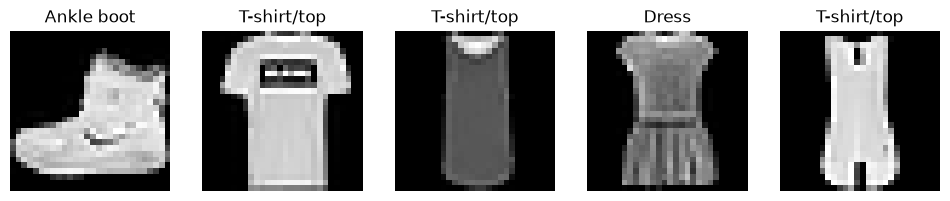

In [197]:
import matplotlib.pyplot as plt

classes = train_ds.classes
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    img, label = train_ds[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(classes[label])
    ax.axis("off")
plt.show()

In [198]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5]),   # 0~1 -> -1~1
])

In [200]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape)   # torch.Size([64, 1, 28, 28])  배치 차원이 생김!
print(labels.shape)   # torch.Size([64])

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [201]:
for images, labels in train_loader:
    pass   # 여기서 모델 학습이 일어날 예정
print("1 에폭 완료. 배치 수:", len(train_loader))   # 60000/64 = 938

1 에폭 완료. 배치 수: 938
